# Notebook 4 — MCMC Parameter Inference

We now combine the observational datasets and sample the posterior distribution using MCMC.

The posterior is:

$$\ln\mathcal{P}(\theta) = \ln\pi(\theta) - \frac{1}{2}\sum_{\text{datasets}} \chi^2(\theta)$$

where $\pi(\theta)$ is the prior and the sum runs over whichever datasets are switched on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import json
import os
from datetime import datetime
from getdist import MCSamples, plots
from utils import *
from chi2 import chi2_sne, chi2_cc, chi2_bao, load_sne

---
## 1. Load datasets `[S1]`

In [2]:
# SNe Ia — Pantheon+
z_sn, mb, dmb = load_sne('pantheon+')
print(f"SNe  : {len(z_sn)} supernovae,  z = {z_sn.min():g} — {z_sn.max():g}")

# cosmic chronometers
z_cc, H_cc, dH_cc = np.loadtxt('../data/cosmic_chrono.txt', unpack=True, skiprows=1)
print(f"CC   : {len(z_cc)} measurements, z = {z_cc.min():g} — {z_cc.max():g}")

# DESI DR2 BAO
data_bao = np.genfromtxt('../data/desi_dr2_bao.txt', dtype=None,
                          encoding=None, names=['tracer','z','obs','val','err'])
mask_DM = data_bao['obs'] == 'DM_rd'
mask_DH = data_bao['obs'] == 'DH_rd'
mask_DV = data_bao['obs'] == 'DV_rd'
z_DM, DM_obs, dDM = data_bao['z'][mask_DM], data_bao['val'][mask_DM], data_bao['err'][mask_DM]
z_DH, DH_obs, dDH = data_bao['z'][mask_DH], data_bao['val'][mask_DH], data_bao['err'][mask_DH]
z_DV, DV_obs, dDV = data_bao['z'][mask_DV], data_bao['val'][mask_DV], data_bao['err'][mask_DV]
z_max_bao = max(z_DM.max(), z_DH.max(), z_DV.max()) * 1.01
print(f"BAO  : {len(z_DM)+len(z_DH)+len(z_DV)} measurements (DESI DR2)")

SNe  : 1580 supernovae,  z = 0.01016 — 2.26137
CC   : 32 measurements, z = 0.07 — 1.965
BAO  : 13 measurements (DESI DR2)


---
## 2. Model and dataset configuration `[S2]`

Set the dark energy model and choose which datasets to include.
Everything else follows automatically.

In [3]:
# --- dark energy model ---
model = 'LCDM'    # 'LCDM', 'CPL', 'lCDM'

# --- datasets ---
use_sne = True
use_cc  = True
use_bao = True

# --- emcee settings ---
n_walkers = 32
n_steps   = 2000
n_burnin  = 500

# ---------------------------------------------------------------------------
# parameter vector, priors, and starting point — set by model
# ---------------------------------------------------------------------------

def model_setup(model):
    """Return (param_names, priors, p0) for the chosen dark energy model."""
    if model == 'LCDM':
        names  = ['Om', 'h']
        priors = [(0.1, 0.9), (0.4, 1.0)]
        p0     = [0.3, 0.7]
    elif model == 'CPL':
        names  = ['Om', 'h', 'w0', 'wa']
        priors = [(0.1, 0.9), (0.4, 1.0), (-2.0, 0.0), (-3.0, 3.0)]
        p0     = [0.3, 0.7, -1.0, 0.0]
    elif model == 'lCDM':
        names  = ['Om', 'h', 'lam']
        priors = [(0.1, 0.9), (0.4, 1.0), (0.0, 2.0)]
        p0     = [0.3, 0.7, 0.5]
    return names, priors, p0

param_names, priors, p0 = model_setup(model)
ndim = len(param_names)

print(f"Model      : {model}")
print(f"Parameters : {param_names}")
print(f"Datasets   : SNe={use_sne}, CC={use_cc}, BAO={use_bao}")
print(f"Walkers    : {n_walkers}  Steps: {n_steps}  Burn-in: {n_burnin}")

Model      : LCDM
Parameters : ['Om', 'h']
Datasets   : SNe=True, CC=True, BAO=True
Walkers    : 32  Steps: 2000  Burn-in: 500


---
## 3. Log-posterior `[S3]`

In [4]:
def log_posterior(theta):
    """Log-posterior for the chosen model and datasets."""
    Om, h = theta[0], theta[1]
    kwargs = {}
    if model == 'CPL':
        kwargs = {'w0': theta[2], 'wa': theta[3]}
    elif model == 'lCDM':
        kwargs = {'lam': theta[2]}

    # flat priors
    for val, (lo, hi) in zip(theta, priors):
        if not lo < val < hi:
            return -np.inf

    # dark energy model — computed once
    rho_de, drho_de = de_model(model, Om, **kwargs)

    lnL = 0.0

    if use_sne:
        chi2, _ = chi2_sne(Om, rho_de, z_sn, mb, dmb)
        lnL -= 0.5 * chi2

    if use_cc:
        lnL -= 0.5 * chi2_cc(Om, h, rho_de, z_cc, H_cc, dH_cc)

    if use_bao:
        z_th, d_c_th, _ = solve_distances(Om, rho_de, z_max=z_max_bao)
        lnL -= 0.5 * chi2_bao(Om, h, rho_de, z_th, d_c_th,
                                z_DM, DM_obs, dDM,
                                z_DH, DH_obs, dDH,
                                z_DV, DV_obs, dDV)

    return lnL

# quick sanity check
print(f"log_posterior at p0 = {log_posterior(p0):.2f}")

log_posterior at p0 = -365.91


---
## 4. Run emcee `[S4]`

In [5]:
# initialise walkers in a small ball around p0
p0_walkers = np.array(p0) + 1e-3 * np.random.randn(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_posterior)

print("Running MCMC...")
sampler.run_mcmc(p0_walkers, n_steps, progress=True)
print("Done.")

Running MCMC...


100%|██████████| 2000/2000 [03:53<00:00,  8.57it/s]

Done.


---
## 5. Save chain `[S5]`

Save the chain and metadata so the analysis can be repeated without rerunning the MCMC.

In [6]:
# discard burn-in and flatten
flat_samples = sampler.get_chain(discard=n_burnin, flat=True)

# build a descriptive filename
datasets_str = '+'.join([d for d, u in [('sne', use_sne), ('cc', use_cc), ('bao', use_bao)] if u])
timestamp    = datetime.now().strftime('%Y%m%d_%H%M')
chain_name   = f'chains/chain_{model}_{datasets_str}_{timestamp}'

# save chain
np.save(f'{chain_name}.npy', flat_samples)

# save metadata
meta = {
    'model':        model,
    'param_names':  param_names,
    'priors':       priors,
    'use_sne':      use_sne,
    'use_cc':       use_cc,
    'use_bao':      use_bao,
    'n_walkers':    n_walkers,
    'n_steps':      n_steps,
    'n_burnin':     n_burnin,
    'n_samples':    flat_samples.shape[0],
    'timestamp':    timestamp,
}
with open(f'{chain_name}.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f"Saved {flat_samples.shape[0]} samples to {chain_name}.npy")
print(f"Metadata saved to {chain_name}.json")

Saved 48000 samples to chains/chain_LCDM_sne+cc+bao_20260710_0820.npy
Metadata saved to chains/chain_LCDM_sne+cc+bao_20260710_0820.json


---
## 6. Convergence check `[S6]`

Check the autocorrelation time and inspect the trace plots.

Autocorrelation times:
  Om: 32.5 steps
  h: 27.9 steps
  => burn-in of 500 steps is sufficient


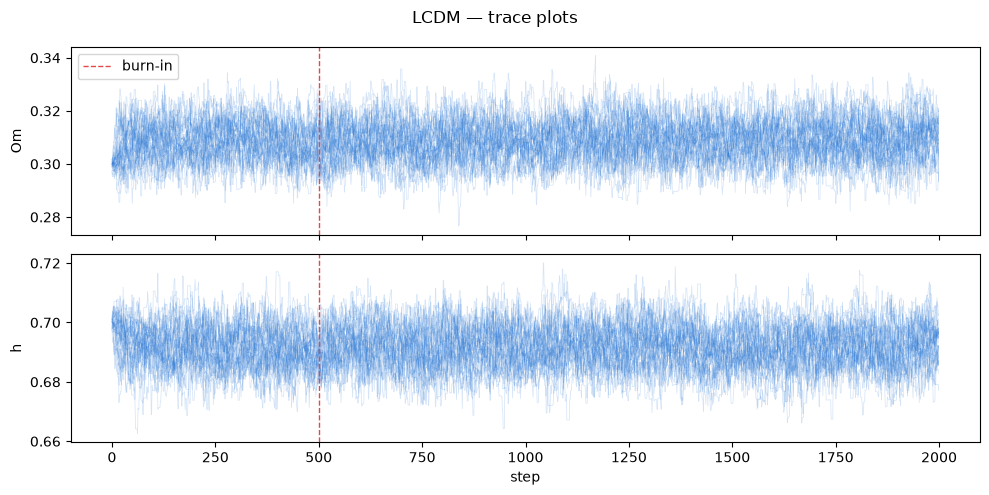

In [7]:
# autocorrelation time
tau = sampler.get_autocorr_time(quiet=True)
print("Autocorrelation times:")
for name, t in zip(param_names, tau):
    print(f"  {name}: {t:.1f} steps")
print(f"  => burn-in of {n_burnin} steps is "
      f"{'sufficient' if n_burnin > 2*tau.max() else 'possibly too short'}")

# trace plots
fig, axes = plt.subplots(ndim, 1, figsize=(10, 2.5*ndim), sharex=True)
if ndim == 1:
    axes = [axes]
for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.plot(sampler.get_chain()[:, :, i], color='#2a78d6', alpha=0.2, lw=0.5)
    ax.axvline(n_burnin, color='#e34948', ls='--', lw=1, label='burn-in')
    ax.set_ylabel(name)
axes[-1].set_xlabel('step')
axes[0].legend(fontsize=10)
plt.suptitle(f'{model} — trace plots')
plt.tight_layout()
plt.show()

---
## 7. Corner plot `[S7]`

Load from a saved chain or use the in-memory samples.

In [10]:
# --- load or use in-memory chain ---
load_chain = False
chain_file = 'chains/chain_LCDM_sne+cc+bao_20260101_1200'  # without extension

if load_chain:
    flat_samples = np.load(f'{chain_file}.npy')
    with open(f'{chain_file}.json') as f:
        meta = json.load(f)
    param_names = meta['param_names']
    model       = meta['model']
    use_sne     = meta['use_sne']
    use_cc      = meta['use_cc']
    use_bao     = meta['use_bao']
    print(f"Loaded {flat_samples.shape[0]} samples from {chain_file}")
    print(f"Model: {model}  |  datasets: SNe={use_sne}, CC={use_cc}, BAO={use_bao}")
else:
    print(f"Using in-memory chain: {flat_samples.shape[0]} samples")

Using in-memory chain: 48000 samples


Removed no burn in


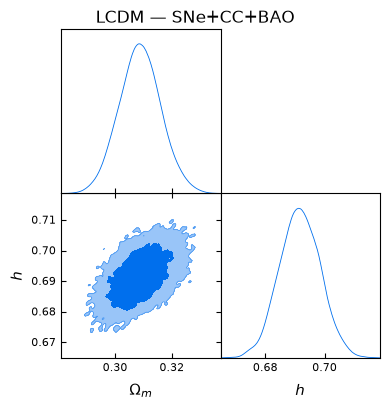


Marginalised constraints (mean ± std):
  Om = 0.3088 ± 0.0074
  h = 0.6916 ± 0.0069


In [11]:
# getdist labels
labels = {
    'Om':  r'\Omega_m',
    'h':   r'h',
    'w0':  r'w_0',
    'wa':  r'w_a',
    'lam': r'\lambda',
}

samples = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=[labels[p] for p in param_names]
)

g = plots.get_subplot_plotter()
g.triangle_plot(samples, filled=True)
datasets_str = '+'.join([d for d, u in [('SNe', use_sne), ('CC', use_cc), ('BAO', use_bao)] if u])
plt.suptitle(f'{model} — {datasets_str}', y=1.01)
plt.show()

# marginalised constraints
print("\nMarginalised constraints (mean ± std):")
for i, name in enumerate(param_names):
    mean = np.mean(flat_samples[:, i])
    std  = np.std(flat_samples[:, i])
    print(f"  {name} = {mean:.4f} ± {std:.4f}")